# Data Cleaning & Visualization Project
## Netflix Dataset

### Project Description
This project demonstrates the complete data analysis workflow using a Netflix dataset. We clean the dataset, handle missing values and duplicates, explore patterns, and visualize insights. The objective is to transform raw data into meaningful information through preprocessing and visualization.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


## Load Dataset
Load the CSV file into a pandas DataFrame.

In [3]:
df = pd.read_csv('netflix.csv')
df.head()

,Name,Year,Age Rating,Duration,Category,,Unnamed: 6,Unnamed: 7,Unnamed: 8,Age Rating.1,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,The Sea Beast,2022.0,7+,1h 59m,Kids & Family Movies,NaN,NaN,NaN,NaN,7+,...,13+,NaN,18+,NaN,16+,NaN,All,NaN,Total Count of Duration,Total Sum of Year
1,Sonic the Hedgehog,2020.0,7+,1h 41m,Kids & Family Movies,NaN,NaN,NaN,Duration,Count of Duration,...,Count of Duration,Sum of Year,Count of Duration,Sum of Year,Count of Duration,Sum of Year,Count of Duration,Sum of Year,NaN,NaN
2,Tom and Jerry,2021.0,7+,1h 41m,Kids & Family Movies,NaN,NaN,NaN,1h 30m,7,...,4,8076,2,4040,NaN,NaN,NaN,NaN,13,26211
3,We Can Be Heroes,2020.0,7+,1h 40m,Kids & Family Movies,NaN,NaN,NaN,1h 46m,7,...,2,4043,NaN,NaN,3,6054,NaN,NaN,12,24236
4,STAND BY ME Doraemon 2,2020.0,7+,1h 37m,Kids & Family Movies,NaN,NaN,NaN,1h 59m,4,...,5,10092,1,2016,2,4032,NaN,NaN,12,24177


## Dataset Overview

In [4]:
print('Shape:',df.shape)
df.info()
df.describe(include='all')

Shape: (2729, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2729 entries, 0 to 2728
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          2728 non-null   object 
 1   Year          2704 non-null   float64
 2   Age Rating    2704 non-null   object 
 3   Duration      2728 non-null   object 
 4   Category      2727 non-null   object 
 5                 0 non-null      float64
 6   Unnamed: 6    0 non-null      float64
 7   Unnamed: 7    0 non-null      float64
 8   Unnamed: 8    144 non-null    object 
 9   Age Rating.1  66 non-null     object 
 10  Values        65 non-null     object 
 11  Unnamed: 11   76 non-null     object 
 12  Unnamed: 12   75 non-null     object 
 13  Unnamed: 13   50 non-null     object 
 14  Unnamed: 14   49 non-null     object 
 15  Unnamed: 15   47 non-null     object 
 16  Unnamed: 16   46 non-null     object 
 17  Unnamed: 17   33 non-null     object 
 18  Unnamed: 1

,Name,Year,Age Rating,Duration,Category,,Unnamed: 6,Unnamed: 7,Unnamed: 8,Age Rating.1,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
count,2728,2704.000000,2704,2728,2727,0.0,0.0,0.0,144,66,...,76,75,50,49,47,46,33,32,144,144
unique,1812,NaN,9,174,69,NaN,NaN,NaN,144,10,...,8,52,7,36,6,30,8,21,14,102
top,Little Women,NaN,13+,1h 30m,Comedies,NaN,NaN,NaN,Duration,1,...,1,2018,1,2021,1,2022,1,2021,1,2021
freq,5,NaN,737,67,457,NaN,NaN,NaN,1,32,...,38,6,28,5,29,7,20,5,54,7
mean,NaN,2014.891642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,8.332022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1954.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Conclusion
Understanding the structure helps identify cleaning tasks and available features.

## Remove Unwanted Columns

In [5]:
df=df.loc[:,~df.columns.str.contains('^Unnamed')]
df.head()

,Name,Year,Age Rating,Duration,Category,,Age Rating.1,Values
0,The Sea Beast,2022.0,7+,1h 59m,Kids & Family Movies,NaN,7+,NaN
1,Sonic the Hedgehog,2020.0,7+,1h 41m,Kids & Family Movies,NaN,Count of Duration,Sum of Year
2,Tom and Jerry,2021.0,7+,1h 41m,Kids & Family Movies,NaN,7,14095
3,We Can Be Heroes,2020.0,7+,1h 40m,Kids & Family Movies,NaN,7,14139
4,STAND BY ME Doraemon 2,2020.0,7+,1h 37m,Kids & Family Movies,NaN,4,8037


### Conclusion
Extra automatically generated columns have been removed.

## Missing Values
Check for missing values before analysis.

In [6]:
df.isnull().sum()

Name               1
Year              25
Age Rating        25
Duration           1
Category           2
                2729
Age Rating.1    2663
Values          2664
dtype: int64

### Conclusion
Columns with missing values should be treated before detailed analysis.

## Duplicate Values

In [7]:
print('Duplicates:',df.duplicated().sum())
df=df.drop_duplicates()

Duplicates: 0


### Conclusion
Duplicate records have been removed.

## Count Plot
This visualization helps understand the dataset.

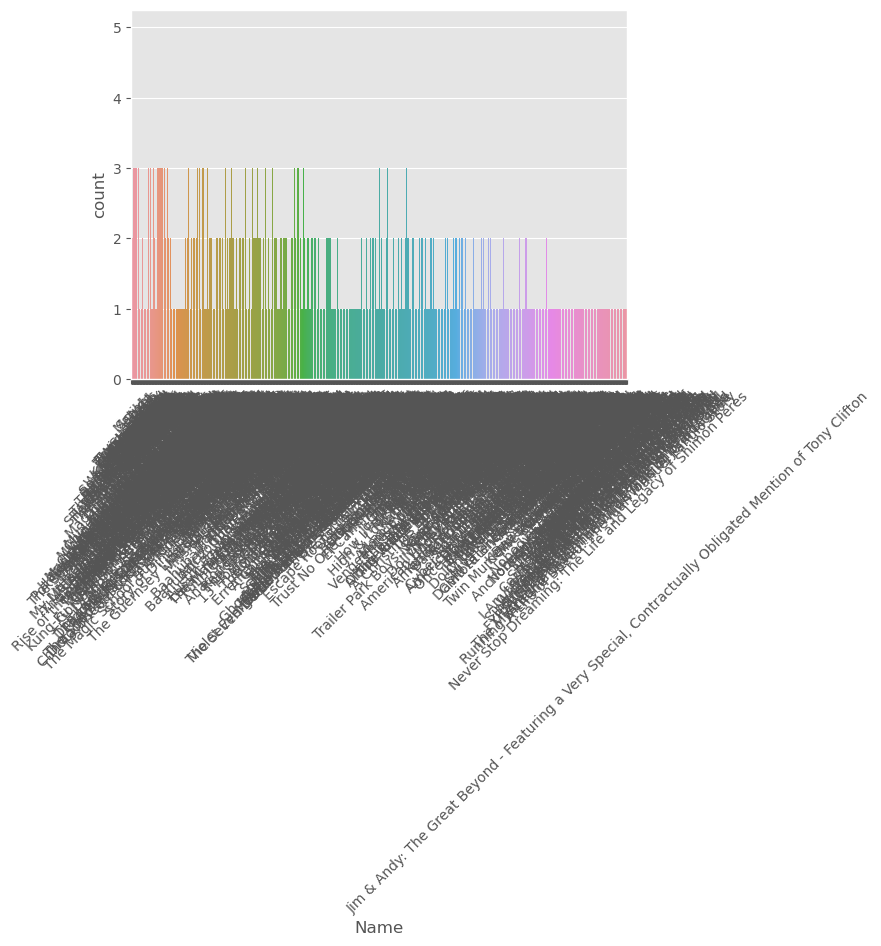

In [8]:
sns.countplot(data=df,x=df.columns[0]);plt.xticks(rotation=45);plt.show()

### Conclusion
Shows frequency of categories.

## Histogram
This visualization helps understand the dataset.

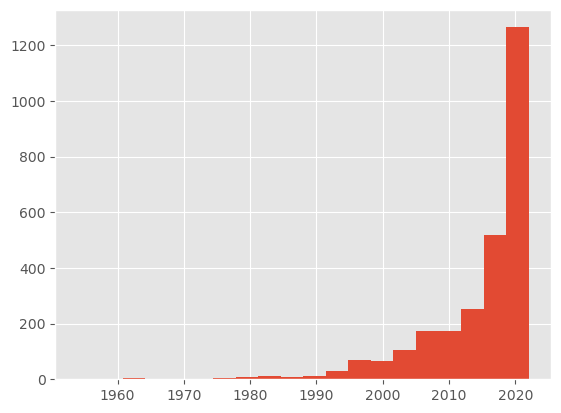

In [9]:
plt.hist(df.select_dtypes(include='number').iloc[:,0],bins=20);plt.show()

### Conclusion
Shows distribution of a numerical feature.

## Box Plot
This visualization helps understand the dataset.

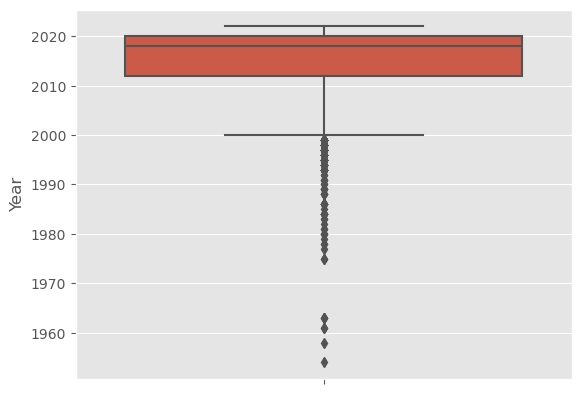

In [10]:
sns.boxplot(y=df.select_dtypes(include='number').iloc[:,0]);plt.show()

### Conclusion
Helps identify outliers.

## Pie Chart
This visualization helps understand the dataset.

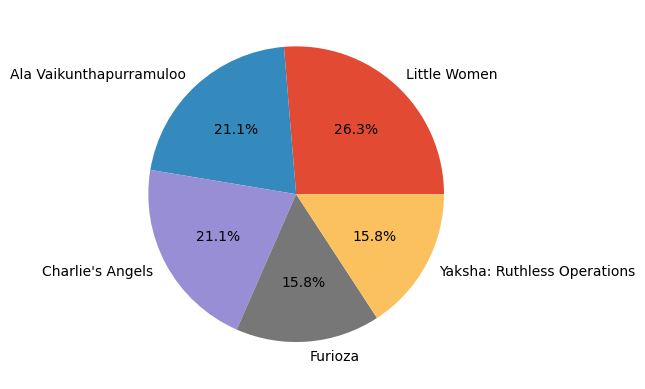

In [11]:
vc=df[df.columns[0]].value_counts().head(5);plt.pie(vc,labels=vc.index,autopct='%1.1f%%');plt.show()

### Conclusion
Shows proportion of top categories.

## Correlation Heatmap
This visualization helps understand the dataset.

c:\Users\kesha\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


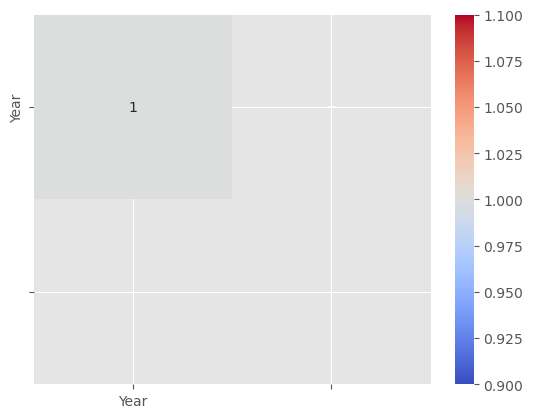

In [12]:
num=df.select_dtypes(include='number');sns.heatmap(num.corr(),annot=True,cmap='coolwarm');plt.show()

### Conclusion
Shows correlation among numeric variables.

# Final Project Conclusion

### Key Findings
- Dataset was cleaned by removing unnecessary columns and duplicate records.
- Missing values were identified before analysis.
- Visualizations revealed the distribution of important variables.
- Box plot highlighted potential outliers.
- Correlation heatmap showed relationships among numerical features.
- The project demonstrates data preprocessing, exploratory data analysis, and storytelling with data using Pandas, Matplotlib, and Seaborn.

This notebook is suitable for showcasing a beginner data analytics project on GitHub.
